RuleBased : TextBlob and Vader


In [1]:
from textblob import TextBlob

In [2]:
s1 = "I am Ashutosh Dash and I am good at Mechanics"
s2 = "I am pretty sure that we are fucked"
s3 = "I am fully convinced that we are flunking the exam"

In [8]:
Senti_score_1  = TextBlob(s2)

In [9]:
type(Senti_score_1)

textblob.blob.TextBlob

In [10]:
Senti_score_1

TextBlob("I am pretty sure that we are fucked")

In [23]:
Senti_score_1.sentiment

Sentiment(polarity=0.05000000000000001, subjectivity=0.8629629629629628)

In [14]:
type(Senti_score_1.sentiment.polarity)

float

In [15]:
print(Senti_score_1.sentiment.polarity)

0.05000000000000001


In [16]:
parts = "bad worse worst good better best excellent outstanding disastrous".split(" ")
for part in parts:
    print(f"{part} : {TextBlob(part).sentiment.polarity}")


bad : -0.6999999999999998
worse : -0.4
worst : -1.0
good : 0.7
better : 0.5
best : 1.0
excellent : 1.0
outstanding : 0.5
disastrous : -0.7


VADER

In [14]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [15]:
VaderSentiment = SentimentIntensityAnalyzer()
type(VaderSentiment)

vaderSentiment.vaderSentiment.SentimentIntensityAnalyzer

In [19]:
VaderSentiment.polarity_scores(s1)

{'neg': 0.0, 'neu': 0.756, 'pos': 0.244, 'compound': 0.4404}

Pre- Trained TRANSFORMERS

In [21]:
import transformers
from transformers import pipeline

In [22]:
sentiment_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


In [29]:
sentiment_pipeline(s2)

[{'label': 'NEGATIVE', 'score': 0.9948103427886963}]

Practical for Sentiment analysis

In [2]:
import pandas as pd
import numpy as np
import re

In [3]:
from pathlib import Path
parentfolder = Path.cwd().parent

In [4]:
data = pd.read_csv(parentfolder.joinpath('Supporting_Docs').joinpath('book_reviews_sample.csv'))

In [35]:
data

,index,reviewText,rating,reviewTextClean,VaderSentiment,transformer,VaderSentiment_label
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684,POSITIVE,Neutral
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325,POSITIVE,Neutral
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740,NEGATIVE,Neutral
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652,NEGATIVE,Neutral
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767,NEGATIVE,Postive
...,...,...,...,...,...,...,...
95,1794,Love this author. I have read most of her book...,5,love this author i have read most of her books...,0.7549,POSITIVE,Neutral
96,6716,This book was not bad! I like the storyline ! ...,2,this book was not bad i like the storyline th...,0.1877,NEGATIVE,Neutral
97,7372,This is part of a series I read and I loved th...,5,this is part of a series i read and i loved th...,0.5994,POSITIVE,Neutral
98,5676,Finally a Texas newspaper in Kindle format.Way...,4,finally a texas newspaper in kindle formatway ...,0.1779,NEGATIVE,Neutral


In [29]:
data['transformer'][0][0]['label']

'POSITIVE'

We dont remove the stopwords as they have meaning in the sentiment analysis

In [10]:
data['reviewTextClean'] = data['reviewText'].str.lower()

In [12]:
data['reviewTextClean'] = data.apply(lambda x : re.sub(r"([^\w\s])","",x['reviewTextClean']), axis = 1)

The reviewTextClean is now free of punctuations and lower case

In [30]:
data['VaderSentiment'] = data.apply(lambda x : VaderSentiment.polarity_scores(x['reviewTextClean'])['compound'], axis = 1)

In [32]:
my_bins = [-1, -.1, .1, 1]
names = ['Postive', 'Negetive', 'Neutral']
data['VaderSentiment_label'] = pd.cut(data['VaderSentiment'],bins=my_bins,labels=names)

In [34]:
data['transformer'] = data.apply(lambda x : sentiment_pipeline(x['reviewTextClean'])[0]['label'], axis=1 )

In [38]:
data['VaderSentiment_label'].value_counts()

VaderSentiment_label
Neutral     68
Postive     19
Negetive    13
Name: count, dtype: int64

In [39]:
data['VaderSentiment_label'].value_counts().plot

<Axes: xlabel='VaderSentiment_label'>

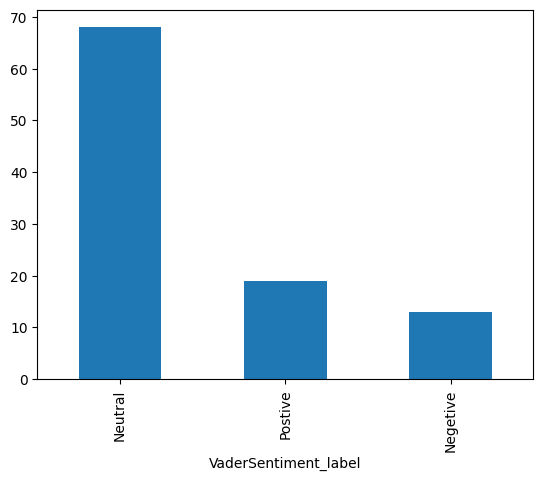

In [ ]:
data['VaderSentiment_label'].value_counts().plot.bar()

<Axes: xlabel='transformer'>

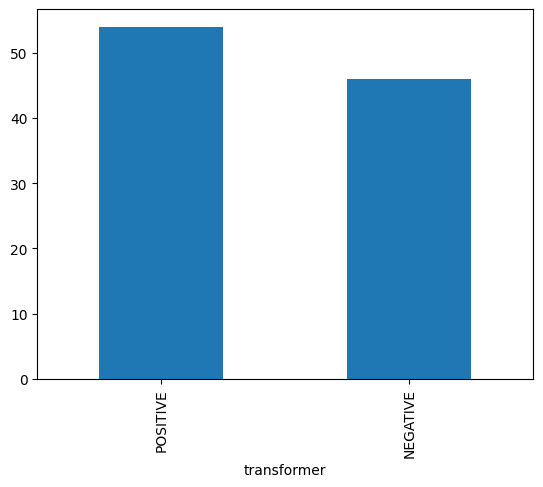

In [37]:
data['transformer'].value_counts().plot.bar()